<a href="https://colab.research.google.com/github/anushabershilla/Data-science-ML/blob/main/houseprice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<bound method NDFrame.head of         price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0    13300000  7420         4          2        3      yes        no       no   
1    12250000  8960         4          4        4      yes        no       no   
2    12250000  9960         3          2        2      yes        no      yes   
3    12215000  7500         4          2        2      yes        no      yes   
4    11410000  7420         4          1        2      yes       yes      yes   
..        ...   ...       ...        ...      ...      ...       ...      ...   
540   1820000  3000         2          1        1      yes        no      yes   
541   1767150  2400         3          1        1       no        no       no   
542   1750000  3620         2          1        1      yes        no       no   
543   1750000  2910         3          1        1       no        no       no   
544   1750000  3850         3          1        2      yes        no       no  

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


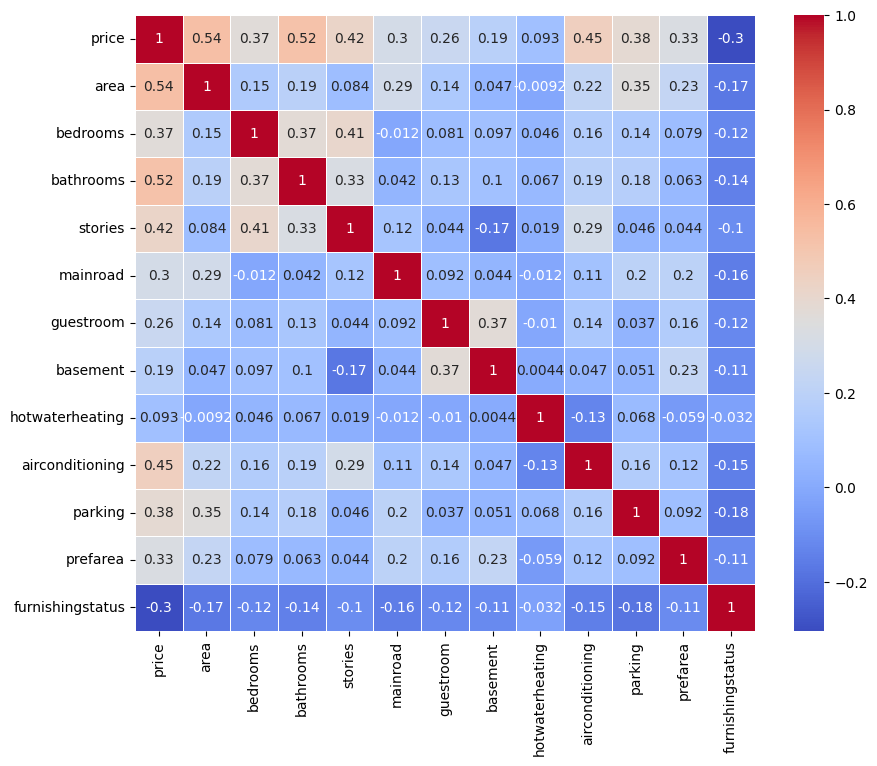

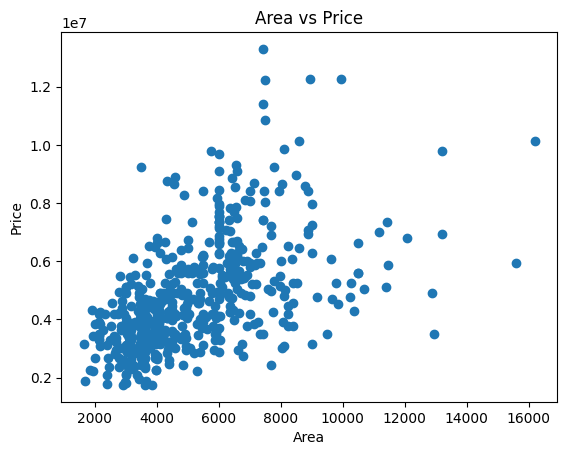

In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv("Housing.csv")
print(df.head)
print(df.shape)
print(df.describe())
print(df.isnull().sum())
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

#Handle categorical colum
df["mainroad"]=df["mainroad"].map({"yes":1,"no":0})
df["guestroom"]=df["guestroom"].map({"yes":1,"no":0})
df["basement"]=df["basement"].map({"yes":1,"no":0})
df['airconditioning']=df['airconditioning'].map({'yes':1,'no':0})
df['prefarea']=df['prefarea'].map({'yes':1,'no':0})
df['hotwaterheating']=df['hotwaterheating'].map({'yes':1,'no':0})
df['furnishingstatus']=df['furnishingstatus'].map({'furnished':1,'semi-furnished':2,'unfurnished':3})
print(df.head())

#Set X and y

x= df.drop("price", axis=1)
print(x)
y= df["price"]

# Train test Split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.4,
    random_state=42
)

# create model and fit
model = LinearRegression()
model.fit(x_train, y_train)
dt_model = DecisionTreeRegressor()
dt_model.fit(x_train, y_train)
rf_model = RandomForestRegressor()
rf_model.fit(x_train, y_train)
#Prediction
y_pred = model.predict(x_test)
y_pred_dt = dt_model.predict(x_test)
y_pred_rf = rf_model.predict(x_test)

#Evaluation
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Linear Regression")
print(f"Mean Absolute Error: {mae}")
print(f"R2 Score: {r2}")

mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)
print("Decision Tree Regression")
print(f"Mean Absolute Error: {mae_dt}")
print(f"R2 Score: {r2_dt}")

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print("Random Forest Regression")
print(f"Mean Absolute Error: {mae_rf}")
print(f"R2 Score: {r2_rf}")

#Predict new house
new_house=[[5000,3,2,2,1,0,0,0,1,2,1,2]]
predicted_price = model.predict(new_house)
print(f"Predicted Price: {predicted_price[0]}")

#correlation heatmap

import seaborn as sns
import matplotlib.pyplot as plt
corr_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.show()

#scatter plt

plt.scatter(df['area'], df['price'])
plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Area vs Price')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Dataset
data = {
    "Area":[1000,1500,1800,2400,3000],
    "Bedrooms":[2,3,3,4,4],
    "Bathrooms":[1,2,2,3,3],
    "Price":[50,65,80,120,150]
}

df = pd.DataFrame(data)
print(df)

# cleaning of data

print(df)
print(df.head())
print (df.shape)
print (df.describe())
print(df.isnull().sum())

#Set X and y

x= df.drop("Price", axis=1)
print(x)
y= df["Price"]

# Train test Split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

# create model and fit

   Area  Bedrooms  Bathrooms  Price
0  1000         2          1     50
1  1500         3          2     65
2  1800         3          2     80
3  2400         4          3    120
4  3000         4          3    150
   Area  Bedrooms  Bathrooms  Price
0  1000         2          1     50
1  1500         3          2     65
2  1800         3          2     80
3  2400         4          3    120
4  3000         4          3    150
   Area  Bedrooms  Bathrooms  Price
0  1000         2          1     50
1  1500         3          2     65
2  1800         3          2     80
3  2400         4          3    120
4  3000         4          3    150
(5, 4)
              Area  Bedrooms  Bathrooms       Price
count     5.000000   5.00000    5.00000    5.000000
mean   1940.000000   3.20000    2.20000   93.000000
std     779.743548   0.83666    0.83666   41.170378
min    1000.000000   2.00000    1.00000   50.000000
25%    1500.000000   3.00000    2.00000   65.000000
50%    1800.000000   3.00000    2